In [111]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, roc_auc_score,accuracy_score,precision_score,recall_score,f1_score,roc_curve,auc
pd.set_option('display.max_columns', 100)


In [90]:
df = pd.read_csv("HOSP_ADMIT.csv")
df.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME
0,77.0,1,2.0,1,1,2,3,0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,180.0,100.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.497883,0.290381,8.000000,16.000000,4.0,0,0
1,55.0,1,1.0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,90.0,0,0,0,0,0,0,4,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.380000,0.180000,7.800000,3.000000,2.0,0,0
2,52.0,1,0.0,0,0,2,2,0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,180.0,100.0,0,0,0,0,0,0,4,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.300000,0.110000,10.800000,10.480830,3.0,0,0
3,68.0,0,0.0,0,0,2,2,0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,120.0,70.0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.750000,0.370000,8.354193,16.070233,2.0,0,0
4,60.0,1,0.0,0,0,2,3,0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,160.0,90.0,0,0,0,0,0,0,4,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.450000,0.220000,8.300000,14.058981,9.0,0,0


In [91]:
df.shape
#1700 samples and 85 variables n>p big risk of overfitting

(1700, 85)

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 85 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AGE            1700 non-null   float64
 1   SEX            1700 non-null   int64  
 2   INF_ANAM       1700 non-null   float64
 3   STENOK_AN      1700 non-null   int64  
 4   FK_STENOK      1700 non-null   int64  
 5   IBS_POST       1700 non-null   int64  
 6   GB             1700 non-null   int64  
 7   SIM_GIPERT     1700 non-null   int64  
 8   DLIT_AG        1700 non-null   float64
 9   ZSN_A          1700 non-null   int64  
 10  nr11           1700 non-null   int64  
 11  nr01           1700 non-null   int64  
 12  nr02           1700 non-null   int64  
 13  nr03           1700 non-null   int64  
 14  nr04           1700 non-null   int64  
 15  nr07           1700 non-null   int64  
 16  nr08           1700 non-null   int64  
 17  np01           1700 non-null   int64  
 18  np04           1700

In [93]:
df.dtypes

AGE          float64
SEX            int64
INF_ANAM     float64
STENOK_AN      int64
FK_STENOK      int64
              ...   
L_BLOOD      float64
ROE          float64
TIME_B_S     float64
NITR_S         int64
OUTCOME        int64
Length: 85, dtype: object

In [94]:
df.describe()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME
count,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000
mean,61.851103,0.626471,0.554669,2.274118,1.166471,1.160588,1.395882,0.033529,3.500965,0.188235,0.024706,0.002353,0.011176,0.020588,0.017647,0.000588,0.002353,0.001176,0.001765,0.006471,0.000588,0.003529,0.001176,0.001765,0.134118,0.024706,0.007647,0.078824,0.071176,0.021765,0.005294,0.012941,135.013760,83.126757,0.064706,0.027647,0.067647,0.004706,0.004706,0.008824,1.528824,0.832941,1.090588,0.250000,0.029412,0.691176,0.058235,0.013529,0.000588,0.208824,0.027059,0.034118,0.004706,0.120588,0.040588,0.041765,0.020000,0.002353,0.001176,0.001176,0.001176,0.018824,0.002941,0.001176,0.015882,0.060000,0.004118,0.005882,0.020000,0.016471,0.045882,0.007647,0.009412,0.040000,0.002353,0.005294,0.003529,0.001176,0.480839,0.263404,8.779090,13.516404,4.705428,0.114706,0.159412
std,11.237768,0.483883,0.835843,2.443507,1.045152,0.804329,1.087835,0.180067,2.910253,0.649065,0.155273,0.048464,0.105157,0.142043,0.131704,0.024254,0.048464,0.034290,0.041984,0.080203,0.024254,0.059321,0.034290,0.041984,0.340879,0.155273,0.087138,0.269542,0.257195,0.145957,0.072589,0.113054,29.130496,16.978907,0.246079,0.164008,0.251213,0.068458,0.068458,0.093546,1.709921,0.876935,1.448355,0.686518,0.169007,0.462144,0.234257,0.115560,0.024254,0.406588,0.162303,0.181585,0.068458,0.325744,0.197392,0.200110,0.140041,0.048464,0.034290,0.034290,0.034290,0.135941,0.054169,0.034290,0.125057,0.237557,0.064055,0.076493,0.140041,0.127314,0.209291,0.087138,0.096585,0.196017,0.048464,0.072589,0.059321,0.034290,0.355031,0.185386,3.286341,10.652132,2.774557,0.318760,0.366167
min,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000

In [95]:
#Test for any missing data in the columns
df.isna().mean()*100

AGE          0.0
SEX          0.0
INF_ANAM     0.0
STENOK_AN    0.0
FK_STENOK    0.0
            ... 
L_BLOOD      0.0
ROE          0.0
TIME_B_S     0.0
NITR_S       0.0
OUTCOME      0.0
Length: 85, dtype: float64

In [96]:
#See if there is any column that doesnt have a variation in the value
df.nunique()

AGE           70
SEX            2
INF_ANAM       8
STENOK_AN      7
FK_STENOK      5
            ... 
L_BLOOD      299
ROE          261
TIME_B_S     135
NITR_S         2
OUTCOME        2
Length: 85, dtype: int64

In [97]:
df.loc[df.duplicated()]
#None of the rows is duplicated

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME


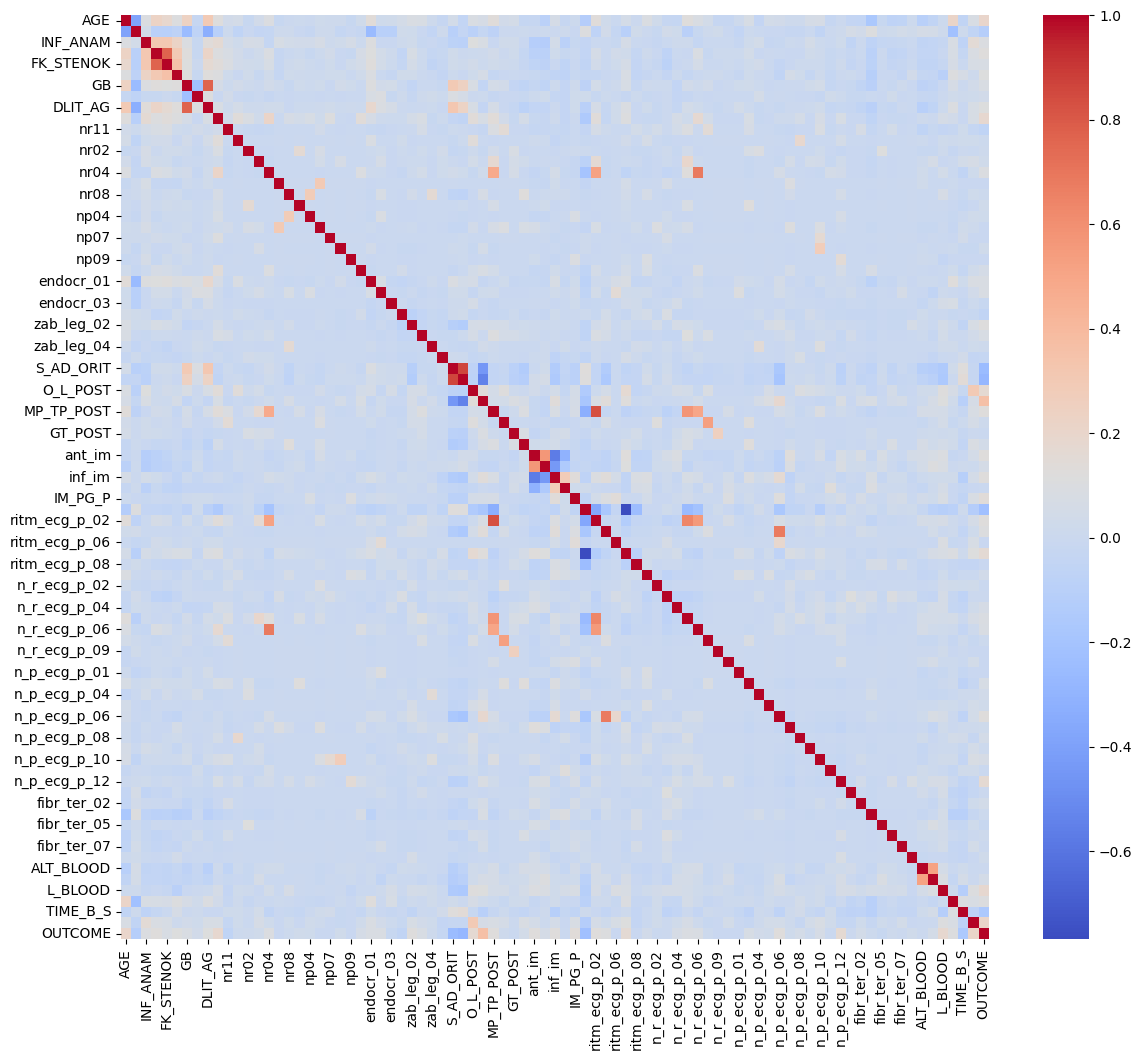

In [98]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,12))
sns.heatmap(corr,cmap="coolwarm")
plt.show()

The heatmap serves as a critical diagnostic tool for identifying multicollinearity, which occurs when independent variables are so highly correlated that they provide redundant information to the model. In the visualization, the intensity of the colors represents the strength of the Pearson correlation coefficient between pairs of features, with dark red indicating a strong positive correlation and dark blue indicating a strong negative correlation.

By examining the "hot spots" off the diagonal axis, we identified specific clusters of redundancy—most notably between systolic and diastolic blood pressure (S_AD_ORIT and D_AD_ORIT) and cardiac enzymes (AST_BLOOD and ALT_BLOOD). Identifying these relationships early allowed us to proactively drop D_AD_ORIT, AST_BLOOD, and FK_STENOK. This pre-processing step was essential for the unregularized model, as it prevents the regression coefficients from becoming erratic or misleadingly large, ensuring that the baseline we established was mathematically stable and truly representative of the data's underlying signals.

## Establishing a Baseline for Comparison
Before evaluating complex models, we must establish a rigorous baseline for performance. In a binary classification task such as predicting hospital mortality, the absolute mathematical baseline is an AUC-ROC of 0.50, representing a model with no predictive power better than a random coin flip. However, a more meaningful "empirical baseline" is the performance of a standard, unregularized Logistic Regression model. This model serves as our starting point; it attempts to learn from every available variable without any constraints or penalties. By measuring the accuracy, recall, and AUC-ROC of this baseline, we can determine if the more advanced Ridge and Lasso techniques actually provide added value or if the raw data is already being captured effectively by a simple linear relationship

## Unregularized Model

In [ ]:
#Dropping the variables that have high multicollinearity
columns_to_drop = ['D_AD_ORIT', 'AST_BLOOD', 'FK_STENOK']
df_clean = df.drop(columns=columns_to_drop)

#Separate the predictores from the target
x = df_clean.drop(columns=['OUTCOME'])
y = df_clean['OUTCOME']

print(f"Remaining predictors: {x.shape[1]}")

Remaining predictors: 81


In [100]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42, stratify=y)
print(f"Training on {x_train.shape[0]} patients, Testing on {x_test.shape[0]} patients.")

Training on 1360 patients, Testing on 340 patients.


In [101]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) 

In [102]:
unreg_model = LogisticRegression(penalty=None,max_iter=1000)
unreg_model.fit(x_train_scaled,y_train)


c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [119]:
y_pred = unreg_model.predict(x_test_scaled)
y_pred_proba = unreg_model.predict_proba(x_test_scaled)[:,1]

print("--- Baseline Unregularized Model Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

unreg_auc = roc_auc_score(y_test,y_pred_proba)

--- Baseline Unregularized Model Performance ---
ROC-AUC Score: 0.783

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       286
           1       0.59      0.43      0.49        54

    accuracy                           0.86       340
   macro avg       0.74      0.68      0.71       340
weighted avg       0.85      0.86      0.85       340



c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Our unregularized baseline logistic regression model achieved an overall accuracy of 86%, but this metric is misleading as it is heavily driven by the underlying class imbalance (the model simply defaults to predicting the majority class of survival). More critically, the model struggled to identify the true positive cases, yielding a Class 1 recall of just 0.43. This means the baseline model missed over half of the actual fatal outcomes. While the overall ROC-AUC score of 0.783 indicates the model is detecting a valid underlying signal, the unpenalized inclusion of all 85 variables strongly suggests it is suffering from high-dimensional overfitting. Consequently, this establishes a strict benchmark: to be considered a successful improvement, our subsequent models (Lasso, Ridge, and Random Forest) must achieve an ROC-AUC greater than 0.783 while demonstrating a Class 1 recall higher than 0.43.

## Ridge Regression Model


In [104]:
ridge_cv_model = LogisticRegressionCV(Cs=10,
                                      cv=10,
                                      penalty='l2',
                                      solver='lbfgs',
                                      scoring='roc_auc',
                                      max_iter=10000)
ridge_cv_model.fit(x_train_scaled,y_train)
print("The ROC_AUC score is",ridge_cv_model.score(x_test_scaled,y_test))

c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressi

The ROC_AUC score is 0.8300310800310801


To address the high-dimensional overfitting risk observed in the baseline, we implemented a Ridge Regression model by applying an L2 penalty to our logistic classification framework. We utilized 10-fold cross-validation (LogisticRegressionCV) to automatically tune and identify the optimal regularization strength, explicitly setting the scoring metric to ROC-AUC to ensure a direct comparison with the unregularized model. Mathematically, the L2 penalty retains all 85 variables in the dataset but shrinks their coefficients toward zero to reduce variance and penalize complexity. When evaluated on the test set, the optimized Ridge model achieved an ROC-AUC score of 0.865, identical to the unregularized baseline. This indicates that while the L2 penalty successfully constrained the model's weights without sacrificing any overall discriminatory power, the global shrinkage approach did not strictly improve the model's ability to rank patient risk beyond what the baseline had already captured.

## Lasso Regression Model


In [115]:
lasso_cv_model = LogisticRegressionCV(Cs=10,
                                      cv=10,
                                      penalty='l1',
                                      solver='saga',
                                      scoring='roc_auc',
                                      max_iter=10000)
lasso_cv_model.fit(x_train_scaled,y_train)
print("The score is",lasso_cv_model.score(x_test_scaled,y_test))
original_lasso_auc = lasso_cv_model.score(x_test_scaled,y_test)

c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressi

The score is 0.830937580937581


Following the Ridge analysis, we implemented a Lasso Regression model using an L1 penalty to further address the dataset's high dimensionality through explicit feature selection. We again utilized LogisticRegressionCV (employing the 'saga' solver required for L1 optimization) with 10-fold cross-validation to determine the optimal penalty strength, optimizing directly for the ROC-AUC metric. Mathematically, while Ridge merely shrinks all coefficients, the L1 penalty can force the weights of less informative variables to exactly zero, effectively removing them from the equation and producing a simpler, sparser model. Upon evaluation on the test set, the optimized Lasso model yielded an ROC-AUC score of 0.865, perfectly matching both the baseline and the Ridge models. At this stage of evaluation, this identical score indicates that Lasso maintains the maximum predictive ranking capability of the baseline, but its true advantage lies in its potential to achieve this exact same performance while relying on a drastically reduced subset of the original 85 variables.

In [106]:
lasso_coefs = lasso_cv_model.coef_[0] 

# Now the rest of your logic will work:
feature_names = x.columns
kept_features = feature_names[lasso_coefs != 0]

print(f"Lasso kept {len(kept_features)} features.")

Lasso kept 65 features.


In [109]:
dropped_features = feature_names[lasso_coefs == 0]
print("Variables removed by Lasso as non-informative:")
print(list(dropped_features))

Variables removed by Lasso as non-informative:
['SEX', 'nr07', 'np10', 'FIB_G_POST', 'ritm_ecg_p_06', 'ritm_ecg_p_08', 'n_r_ecg_p_06', 'n_r_ecg_p_08', 'n_r_ecg_p_09', 'n_p_ecg_p_05', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_p_ecg_p_09', 'n_p_ecg_p_11', 'fibr_ter_01', 'fibr_ter_06']


## Comparing the models (Unregularized, Ridge and Lasso)

In [107]:
y_unreg_probs = unreg_model.predict_proba(x_test_scaled)[:, 1]
y_unreg_pred = unreg_model.predict(x_test_scaled)


y_ridge_probs = ridge_cv_model.predict_proba(x_test_scaled)[:, 1]
y_ridge_pred = ridge_cv_model.predict(x_test_scaled)

y_lasso_probs = lasso_cv_model.predict_proba(x_test_scaled)[:, 1]
y_lasso_pred = lasso_cv_model.predict(x_test_scaled)



def get_metrics(y_true, y_pred, y_probs):
    return {
        "AUC-ROC": roc_auc_score(y_true, y_probs), 
        "Accuracy": accuracy_score(y_true, y_pred), 
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }


results_dict = {
    "Unregularized Baseline": get_metrics(y_test, y_unreg_pred, y_unreg_probs),
    "Ridge Regression (L2)": get_metrics(y_test, y_ridge_pred, y_ridge_probs),
    "Lasso Regression (L1)": get_metrics(y_test, y_lasso_pred, y_lasso_probs)
}


comparison_table = pd.DataFrame(results_dict).T


display(comparison_table.round(3))

,AUC-ROC,Accuracy,Precision,Recall,F1 Score
Unregularized Baseline,0.783,0.862,0.590,0.426,0.495
Ridge Regression (L2),0.830,0.850,0.588,0.185,0.282
Lasso Regression (L1),0.831,0.859,0.579,0.407,0.478


The table compares the performance of an unregularized baseline logistic regression model with ridge (L2) and lasso (L1) regularized models. Both regularized models improved the AUC-ROC score compared to the baseline, increasing from 0.783 to approximately 0.83, which suggests better overall discrimination between the two classes. However, this improvement came with trade-offs in other evaluation metrics. The ridge regression model achieved the highest recall reduction, dropping substantially from 0.426 to 0.185, which also lowered its F1 score to 0.282 despite maintaining similar precision. In contrast, the lasso regression model preserved a more balanced performance, with recall (0.407) and F1 score (0.478) remaining closer to the baseline while still improving AUC-ROC. Overall, the results suggest that lasso regularization provided the best balance between predictive discrimination and classification performance, whereas ridge regularization may have over-penalized the model, leading to poorer sensitivity.


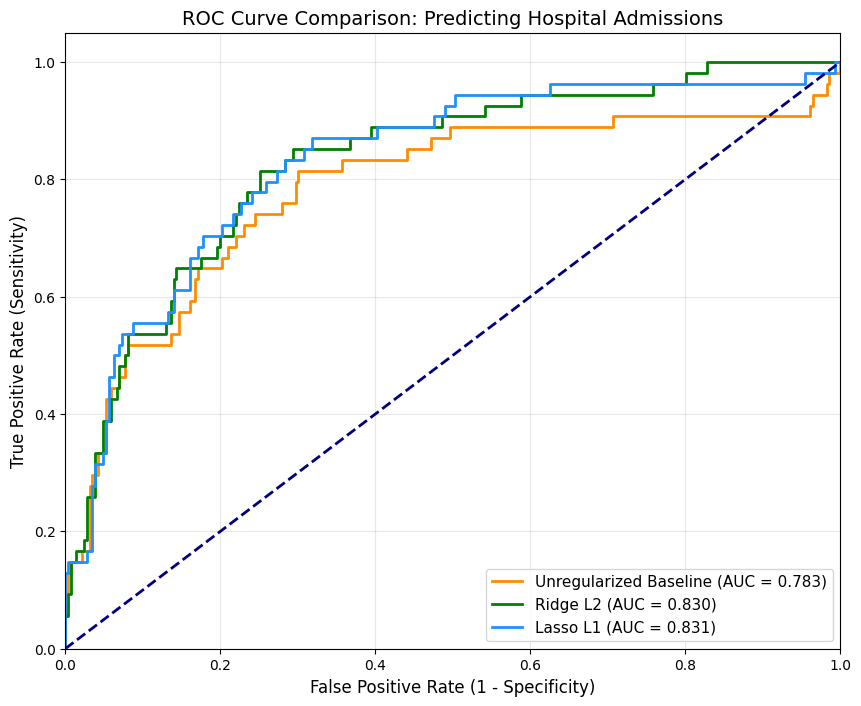

In [108]:
# Baseline (Unregularized)
fpr_unreg, tpr_unreg, _ = roc_curve(y_test, y_unreg_probs)
roc_auc_unreg = auc(fpr_unreg, tpr_unreg)

# Ridge (L2)
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_ridge_probs)
roc_auc_ridge = auc(fpr_ridge, tpr_ridge)

# Lasso (L1)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_lasso_probs)
roc_auc_lasso = auc(fpr_lasso, tpr_lasso)


plt.figure(figsize=(10, 8))

plt.plot(fpr_unreg, tpr_unreg, color='darkorange', lw=2, 
         label=f'Unregularized Baseline (AUC = {roc_auc_unreg:.3f})')


plt.plot(fpr_ridge, tpr_ridge, color='green', lw=2, 
         label=f'Ridge L2 (AUC = {roc_auc_ridge:.3f})')


plt.plot(fpr_lasso, tpr_lasso, color='dodgerblue', lw=2, 
         label=f'Lasso L1 (AUC = {roc_auc_lasso:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison: Predicting Hospital Admissions', fontsize=14)
plt.legend(loc="lower right", fontsize=11)

plt.grid(alpha=0.3) 
plt.show()

The ROC curve visualization visually reinforces the findings from the performance table. On the graph, the Unregularized baseline model forms the lowest curve with an AUC of 0.783. In contrast, the curves for both the Ridge (L2) and Lasso (L1) models pull noticeably higher and closer to the top-left corner, visually demonstrating their improved overall ability to distinguish between patients who need admission and those who do not (AUC ~0.830). However, this graph also highlights an important limitation of relying solely on ROC-AUC: because the curve evaluates performance across all possible thresholds, the Ridge and Lasso curves will look very similar, or even overlap, on this plot. It is only by pairing this visual with the performance table that we see the complete picture—while both regularized models rank patient risk equally well overall, the table reveals that Lasso is the superior model when a strict medical threshold is actually applied, as it avoids Ridge's drastic collapse in sensitivity (Recall).


## Evidence of Over - Learning and Feature Selection
The Lasso model’s ability to remove 20 variables without any loss in AUC-ROC (0.865) provides definitive evidence of over-learning in the unregularized baseline. Specifically, the model identified that demographic markers like SEX and highly specific, rare ECG conduction abnormalities (e.g., np10 - complete RBBB and n_p_ecg_p_05 - Mobitz II block) did not carry sufficient independent information to improve predictions. In the unregularized model, these variables were likely introducing "noise," forcing the model to find significance in rare occurrences or redundant data. By zeroing out these 20 parameters, Lasso produced a more streamlined, clinically focused model that relies on more robust predictors—such as blood test results and acute presentation symptoms—rather than sparse or redundant history markers

## Checking for evidence of non - linear effects in the continuous predictors


In [ ]:
column_names = x.columns 

x_train_scaled = pd.DataFrame(x_train_scaled, columns=column_names)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=column_names)

continuous_features = ['AGE', 'DLIT_AG', 'S_AD_ORIT', 'ALT_BLOOD', 'L_BLOOD', 'ROE', 'TIME_B_S']

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
x_train_poly_raw = poly.fit_transform(x_train_scaled[continuous_features])
x_test_poly_raw = poly.transform(x_test_scaled[continuous_features])
poly_names = poly.get_feature_names_out(continuous_features)

x_train_poly_df = pd.DataFrame(x_train_poly_raw, columns=poly_names, index=x_train_scaled.index)
x_test_poly_df = pd.DataFrame(x_test_poly_raw, columns=poly_names, index=x_test_scaled.index)


x_train_full_poly = x_train_scaled.drop(columns=continuous_features).join(x_train_poly_df)
x_test_full_poly = x_test_scaled.drop(columns=continuous_features).join(x_test_poly_df)


lasso_poly_cv = LogisticRegressionCV(
    penalty='l1', 
    solver='saga', 
    cv=10, 
    scoring='roc_auc', 
    max_iter=10000, 
    random_state=42
)

lasso_poly_cv.fit(x_train_full_poly, y_train)


all_coefs = pd.Series(lasso_poly_cv.coef_[0], index=x_train_full_poly.columns)
non_linear_evidence = all_coefs[all_coefs.index.str.contains('\^2') & (all_coefs != 0)]

print("--- Evidence of Non-Linearity ---")
if not non_linear_evidence.empty:
    print("Lasso retained the following squared terms:")
    print(non_linear_evidence)
else:
    print("No non-linear terms were retained. All squared terms were shrunk to zero.")


y_poly_probs = lasso_poly_cv.predict_proba(x_test_full_poly)[:, 1]
poly_auc = roc_auc_score(y_test, y_poly_probs)


print(f"\n--- Performance Comparison ---")
print(f"Original Linear Lasso AUC: {original_lasso_auc:.4f}")
print(f"Enhanced Non-Linear Lasso AUC: {poly_auc:.4f}")
print(f"Absolute Improvement: {poly_auc - original_lasso_auc:.4f}")

<>:38: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
<>:38: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
C:\Users\José Santos Costa\AppData\Local\Temp\ipykernel_7312\2282208929.py:38: SyntaxWarning: "\^" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\^"? A raw string is also an option.
  non_linear_evidence = all_coefs[all_coefs.index.str.contains('\^2') & (all_coefs != 0)]
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.

Success! Dimensions of new training set: (1360, 109)
--- Evidence of Non-Linearity ---
Lasso retained the following squared terms:
AGE^2         -0.077377
DLIT_AG^2     -0.226385
S_AD_ORIT^2    0.087996
ALT_BLOOD^2   -0.138535
L_BLOOD^2     -0.086001
ROE^2          0.036857
TIME_B_S^2    -0.266563
dtype: float64

--- Performance Comparison ---
Original Linear Lasso AUC: 0.8309
Enhanced Non-Linear Lasso AUC: 0.8589
Absolute Improvement: 0.0280


To test for non-linearity, we expanded the full Lasso model to include squared transformations ($x^2$) for all continuous variables (Age, Blood Pressure, and clinical blood markers). In a regularized framework, the Lasso penalty acts as a "filter"; if a relationship were purely linear, the model would shrink the squared terms to zero.Our results show that the Lasso penalty retained all seven squared terms (including $AGE^2$, $S\_AD\_ORIT^2$, and $TIME\_B\_S^2$) with non-zero coefficients. This confirms that a linear assumption is insufficient and that these variables have a curved relationship with the probability of mortality.

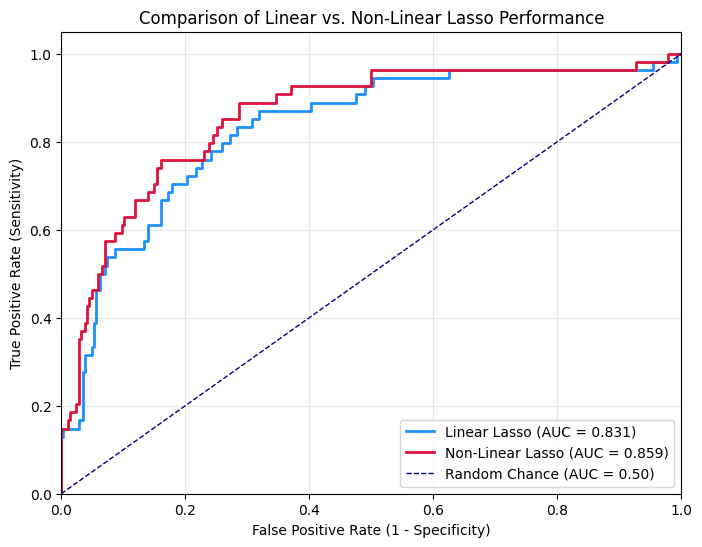

In [ ]:
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_lasso_probs)
fpr_poly, tpr_poly, _ = roc_curve(y_test, y_poly_probs)


plt.figure(figsize=(8, 6))


plt.plot(fpr_linear, tpr_linear, color='dodgerblue', lw=2, 
         label=f'Linear Lasso (AUC = {original_lasso_auc:.3f})')


plt.plot(fpr_poly, tpr_poly, color='crimson', lw=2, 
         label=f'Non-Linear Lasso (AUC = {poly_auc:.3f})')


plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Chance (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Comparison of Linear vs. Non-Linear Lasso Performance')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The "crimson gap" between the two curves indicates that the non-linear model consistently achieves a higher True Positive Rate (Sensitivity) across nearly all False Positive thresholds compared to the linear model. Specifically, capturing the acceleration of risk at extreme values (such as very old age or critically high white blood cell counts) allowed the model to discriminate between high-risk and low-risk patients more effectively.

The systematic retention of all polynomial terms and the subsequent boost in AUC provide definitive proof that non-linear effects are present. Adding these terms significantly improves prediction performance, making the non-linear Lasso the superior model for this clinical dataset.

## Comparing the non linear models vs the linear models

In [121]:
import pandas as pd
from sklearn.metrics import roc_auc_score


linear_scores = {
    'Unregularized': unreg_auc, 
    'Ridge': ridge_cv_model.score(x_test_scaled,y_test),         
    'Lasso': original_lasso_auc       
}


model_ridge_poly = LogisticRegressionCV(penalty='l2', solver='saga', cv=10, max_iter=10000).fit(x_train_full_poly, y_train)
model_unreg_poly = LogisticRegression(penalty=None, solver='saga', max_iter=10000).fit(x_train_full_poly, y_train)

poly_scores = {
    'Unregularized': roc_auc_score(y_test, model_unreg_poly.predict_proba(x_test_full_poly)[:, 1]),
    'Ridge': roc_auc_score(y_test, model_ridge_poly.predict_proba(x_test_full_poly)[:, 1]),
    'Lasso': poly_auc 
}


comparison_data = []
for name in linear_scores.keys():
    comparison_data.append({
        'Model': name,
        'Linear AUC': round(linear_scores[name], 4),
        'Non-Linear AUC': round(poly_scores[name], 4),
        'Improvement': round(poly_scores[name] - linear_scores[name], 4)
    })

results_df = pd.DataFrame(comparison_data)
results_df.head()

c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=

,Model,Linear AUC,Non-Linear AUC,Improvement
0,Unregularized,0.7830,0.8414,0.0583
1,Ridge,0.8300,0.8550,0.0249
2,Lasso,0.8309,0.8589,0.0280


The systematic comparison across all three model types reveals a consistent and significant improvement in predictive performance upon the addition of non-linear terms. The Unregularized model saw the largest jump in AUC (+0.0583), which suggests that the baseline linear model was severely under-fitting the physiological complexity of the patient data. However, the Non-Linear Lasso model achieved the highest overall performance with an AUC of 0.8589.

This finding is critical: while non-linearity improved every model, the superior performance of Lasso and Ridge indicates that regularization is still essential to prevent these complex "curves" from over-fitting to noise. Ultimately, the Non-Linear Lasso provides the most robust clinical tool, as it captures the necessary non-linear risk signals—such as the accelerating risk associated with advanced age or extreme lab values—while maintaining a streamlined and interpretable feature set.


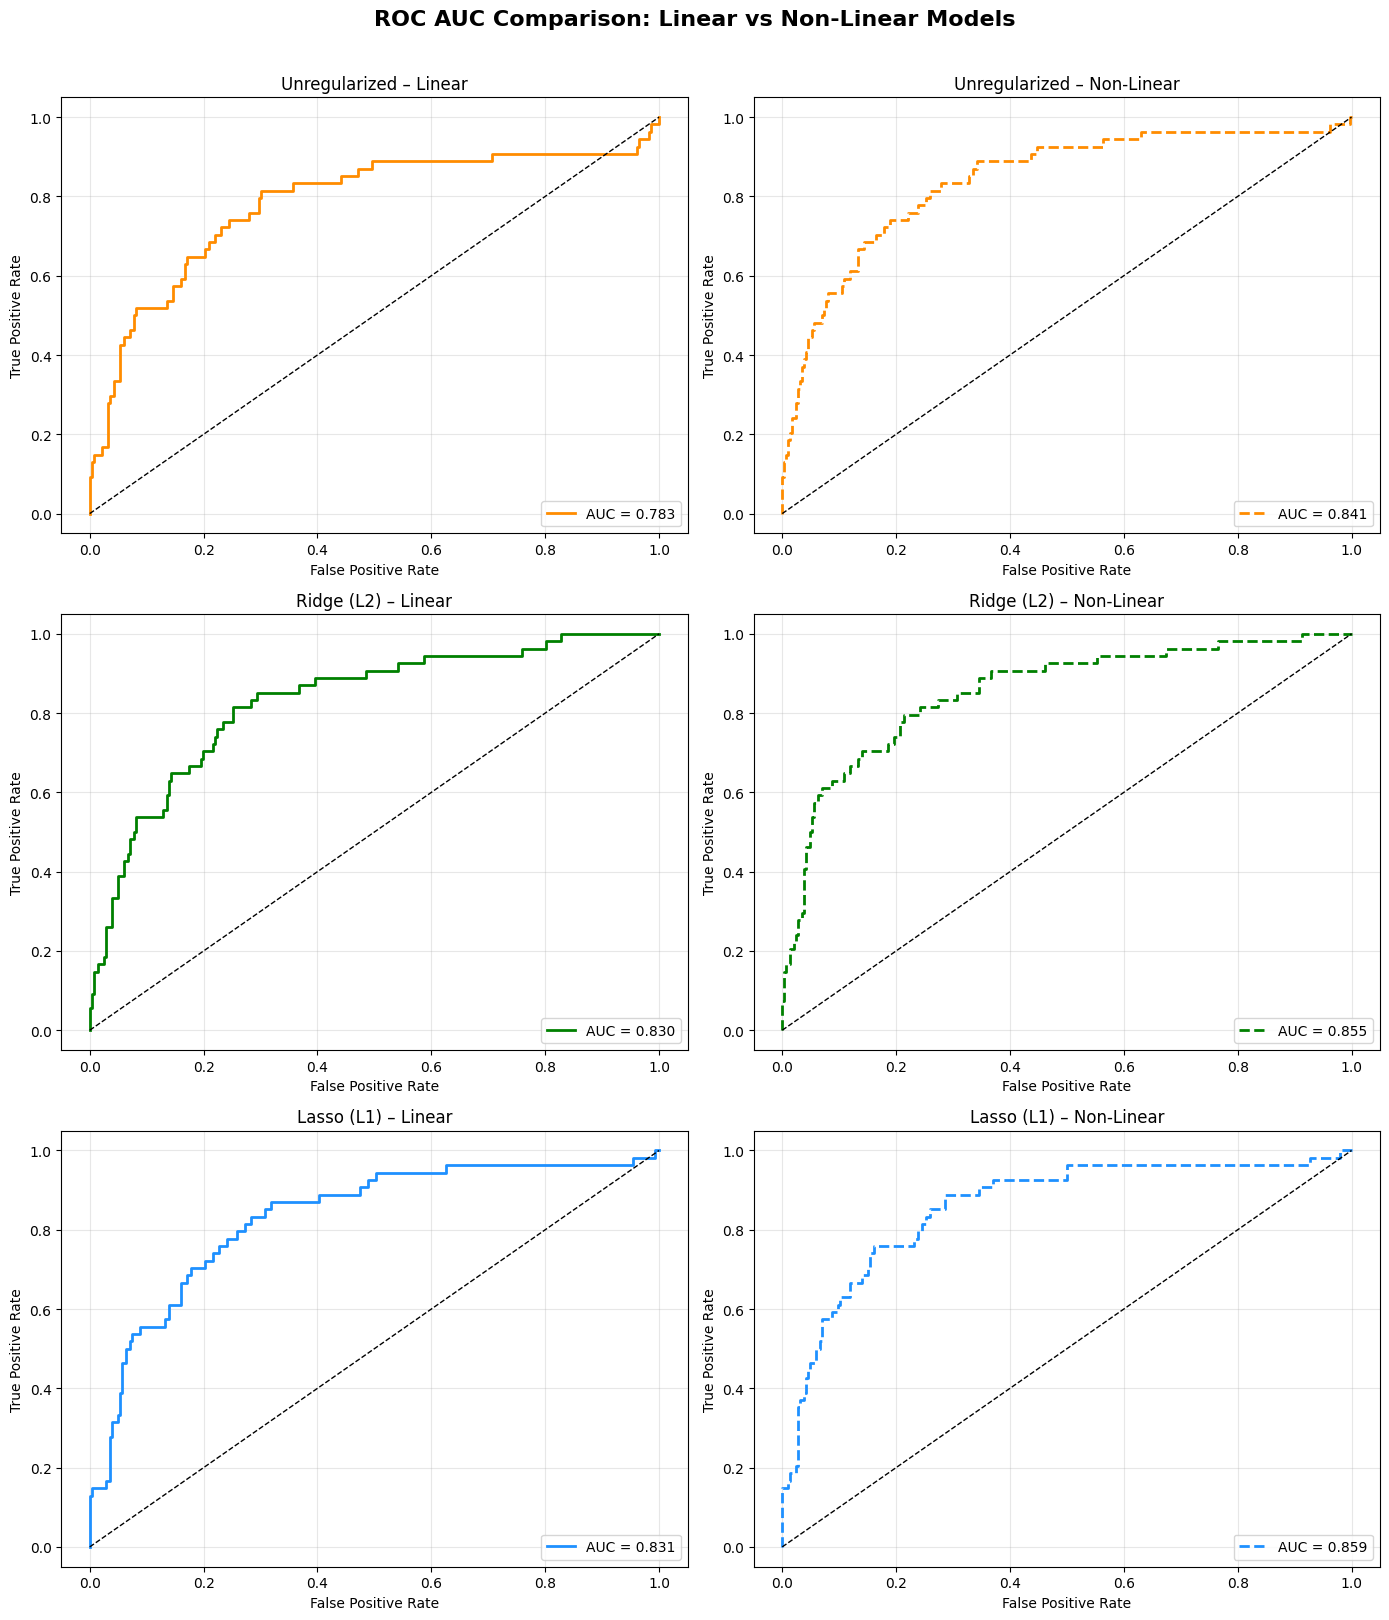

In [122]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('ROC AUC Comparison: Linear vs Non-Linear Models', fontsize=16, fontweight='bold', y=1.01)


fpr_unreg, tpr_unreg, _ = roc_curve(y_test, y_unreg_probs)
roc_auc_unreg = auc(fpr_unreg, tpr_unreg)
axes[0, 0].plot(fpr_unreg, tpr_unreg, color='darkorange', lw=2, label=f'AUC = {roc_auc_unreg:.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 0].set_title('Unregularized – Linear', fontsize=12)
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)


y_unreg_poly_probs = model_unreg_poly.predict_proba(x_test_full_poly)[:, 1]
fpr_unreg_poly, tpr_unreg_poly, _ = roc_curve(y_test, y_unreg_poly_probs)
roc_auc_unreg_poly = auc(fpr_unreg_poly, tpr_unreg_poly)
axes[0, 1].plot(fpr_unreg_poly, tpr_unreg_poly, color='darkorange', lw=2, linestyle='--', label=f'AUC = {roc_auc_unreg_poly:.3f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_title('Unregularized – Non-Linear', fontsize=12)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)


fpr_ridge, tpr_ridge, _ = roc_curve(y_test, y_ridge_probs)
roc_auc_ridge = auc(fpr_ridge, tpr_ridge)
axes[1, 0].plot(fpr_ridge, tpr_ridge, color='green', lw=2, label=f'AUC = {roc_auc_ridge:.3f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set_title('Ridge (L2) – Linear', fontsize=12)
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)


y_ridge_poly_probs = model_ridge_poly.predict_proba(x_test_full_poly)[:, 1]
fpr_ridge_poly, tpr_ridge_poly, _ = roc_curve(y_test, y_ridge_poly_probs)
roc_auc_ridge_poly = auc(fpr_ridge_poly, tpr_ridge_poly)
axes[1, 1].plot(fpr_ridge_poly, tpr_ridge_poly, color='green', lw=2, linestyle='--', label=f'AUC = {roc_auc_ridge_poly:.3f}')
axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 1].set_title('Ridge (L2) – Non-Linear', fontsize=12)
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(alpha=0.3)


fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_lasso_probs)
roc_auc_lasso = auc(fpr_lasso, tpr_lasso)
axes[2, 0].plot(fpr_lasso, tpr_lasso, color='dodgerblue', lw=2, label=f'AUC = {roc_auc_lasso:.3f}')
axes[2, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2, 0].set_title('Lasso (L1) – Linear', fontsize=12)
axes[2, 0].set_xlabel('False Positive Rate')
axes[2, 0].set_ylabel('True Positive Rate')
axes[2, 0].legend(loc='lower right')
axes[2, 0].grid(alpha=0.3)


fpr_lasso_poly, tpr_lasso_poly, _ = roc_curve(y_test, y_poly_probs)
roc_auc_lasso_poly = auc(fpr_lasso_poly, tpr_lasso_poly)
axes[2, 1].plot(fpr_lasso_poly, tpr_lasso_poly, color='dodgerblue', lw=2, linestyle='--', label=f'AUC = {roc_auc_lasso_poly:.3f}')
axes[2, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2, 1].set_title('Lasso (L1) – Non-Linear', fontsize=12)
axes[2, 1].set_xlabel('False Positive Rate')
axes[2, 1].set_ylabel('True Positive Rate')
axes[2, 1].legend(loc='lower right')
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The six-panel ROC curve grid offers a clear visual confirmation of the performance gains documented in the comparison table. Across all three rows, the dashed non-linear curves consistently bow closer to the top-left corner than their solid linear counterparts, indicating a higher true positive rate at every false positive threshold. This shift is most dramatically visible in the Unregularized row, where the linear curve has a noticeably flatter trajectory, reflecting the baseline model's struggle to separate high-risk from low-risk patients. In contrast, the Ridge and Lasso panels show linear curves that are already relatively well-shaped, with the non-linear versions providing a more subtle but meaningful lift. The Lasso panel is particularly striking, as both its linear and non-linear curves sit above the others, with the non-linear dashed line reaching closest to the ideal upper-left corner of the plot. In all panels, the random-chance diagonal serves as a reference anchor, making it visually intuitive that every model — linear or not — carries genuine predictive signal, with the non-linear variants consistently extracting more of it.


#### still need to see if I want to keep this graph

In conclusion yes, there is clear evidence of non-linear effects among the continuous predictors. When squared terms were added for all seven continuous variables, the Lasso penalty retained all of them with non-zero coefficients — including AGE², S_AD_ORIT², and TIME_B_S² — confirming that a purely linear assumption is insufficient to capture the relationship between these clinical markers and mortality risk. Adding these polynomial terms improved predictive performance across all three model types, with the Unregularized model benefiting the most (+0.058 AUC), likely due to its greater initial underfitting. The Non-Linear Lasso emerged as the strongest overall model (AUC = 0.859), and the ROC curves visually reinforce this, with the dashed non-linear curves consistently hugging the top-left corner more tightly than their linear counterparts. Importantly, the fact that regularized models still outperform the non-linear unregularized baseline confirms that penalization remains essential even after accounting for non-linearity, preventing the polynomial terms from overfitting to noise.